# **Amazon Prime TV Shows and Movies Analysis**

# **Project Summary**

In this project, we performed Exploratory Data Analysis (EDA) on the Amazon Prime TV Shows and Movies dataset to gain meaningful insights into the platform’s content distribution, genre trends, and user engagement patterns. The objective of this analysis was to understand how content is structured on the platform and identify key patterns that can help in decision-making and content strategy.

The dataset used in this project consists of information about various titles available on Amazon Prime, including attributes such as content type (movie or TV show), release year, genres, IMDb ratings, and popularity scores. By analyzing these features, we aimed to uncover trends related to content growth, audience preferences, and performance metrics.

The project follows a structured data analysis pipeline. It begins with data loading and initial exploration to understand the dataset’s structure, followed by data cleaning to handle missing values and inconsistencies. Special attention was given to handling both numerical and categorical data appropriately to ensure the accuracy of the analysis.

Further, multiple visualizations were created to explore different aspects of the dataset. These include analyzing the distribution of movies and TV shows, identifying the most common genres, studying the trend of content release over time, examining the distribution of IMDb ratings, and understanding the relationship between ratings and popularity.

One key step in the analysis was transforming the genres column, which originally contained multiple values in a single entry. This was processed using splitting and exploding techniques to enable a more accurate genre-level analysis.

The insights derived from this analysis highlight important trends such as the dominance of movies over TV shows, the popularity of certain genres like drama and comedy, and the rapid growth of content in recent years. Additionally, the analysis shows that popularity is influenced by multiple factors and is not solely dependent on ratings.

Overall, this project demonstrates how exploratory data analysis can be used to extract valuable insights from raw data. These insights can be useful for understanding audience behavior, improving content recommendations, and making strategic decisions in the streaming industry.

## **GitHub link**

# **Problem Statement**

The objective of this project is to perform exploratory data analysis (EDA) on the Amazon Prime TV Shows and Movies dataset to extract meaningful insights about the platform’s content.

The analysis focuses on understanding the distribution and characteristics of content available on Amazon Prime, including identifying the most common genres, analyzing the balance between movies and TV shows, and studying how content production has evolved over time.

Additionally, the project aims to examine the relationship between IMDb ratings and content popularity, and to identify patterns in audience preferences. The dataset also allows for analysis of content diversity and regional availability based on production countries.

Through this analysis, the goal is to answer key questions such as:
- Which genres are most dominant on the platform?
- How has content production changed over the years?
- What is the distribution between movies and TV shows?
- Is there a relationship between ratings and popularity?

By addressing these questions, the project demonstrates how data analysis techniques can be used to derive actionable insights that can support content strategy and decision-making in the streaming industry.

# **Dataset Description**

The dataset used in this project contains information about TV shows and movies available on Amazon Prime. It consists of two files: titles and credits.

The titles dataset is the primary dataset used for analysis and includes details such as title name, type of content (movie or TV show), release year, genres, IMDb score, and popularity metrics. These features are essential for understanding content distribution, audience preferences, and trends over time.

The credits dataset contains information about cast and crew, including actors and directors. However, for this analysis, the focus was primarily on the titles dataset, as it contains the necessary attributes required for exploratory data analysis.

Key columns in the titles dataset include:
- title: Name of the movie or TV show  
- type: Indicates whether the content is a movie or TV show  
- release_year: Year in which the content was released  
- genres: Categories or genres associated with the content  
- imdb_score: Rating of the content based on IMDb  
- tmdb_popularity: Popularity score of the content  

This dataset provides a comprehensive view of the content available on Amazon Prime, enabling meaningful analysis of trends, patterns, and user preferences.

**1. Import Libraries**

This section imports all the necessary libraries required for data analysis and visualization.

In [48]:
# Import libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

**2. Load Dataset**

The dataset is loaded into the notebook for further analysis.

In [49]:
from google.colab import files
uploaded = files.upload()

Saving credits.csv to credits (2).csv
Saving titles.csv to titles (2).csv


In [50]:
# Load dataset files
titles = pd.read_csv('titles.csv')
credits = pd.read_csv('credits.csv')

# Display first few rows
titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [51]:
# Check column names
titles.columns
# Get dataset info
titles.info()
# Summary statistics
titles.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


**4. Data Cleaning**

Missing values are handled to ensure accurate analysis. Numerical and categorical columns are treated separately.

In [52]:
# Check missing values
titles.isnull().sum()

# Separate numeric and categorical columns
num_cols = titles.select_dtypes(include=['float64', 'int64']).columns
cat_cols = titles.select_dtypes(include=['object']).columns

# Fill numeric values with median
titles[num_cols] = titles[num_cols].fillna(titles[num_cols].median())

# Fill categorical values with 'Unknown'
titles[cat_cols] = titles[cat_cols].fillna('Unknown')

**5. Data Analysis and Visualizations**

This section includes various visualizations to analyze trends, distributions, and relationships in the dataset.

This graph shows the distribution of movies and TV shows on Amazon Prime.

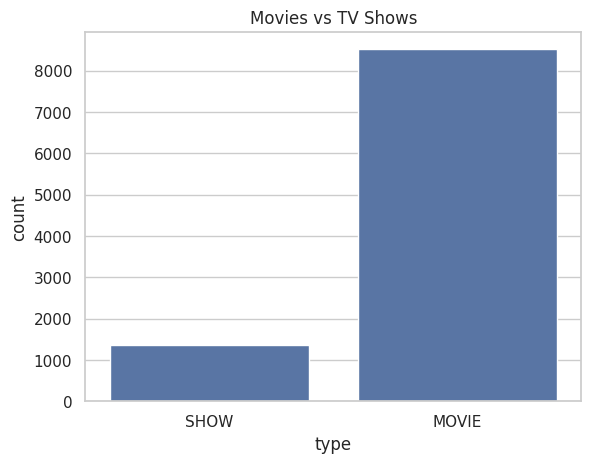

In [53]:
# Plot distribution of movies vs TV shows
sns.countplot(x='type', data=titles)
plt.title("Movies vs TV Shows")
plt.show()

 The graph below highlights the most common genres available on the platform.

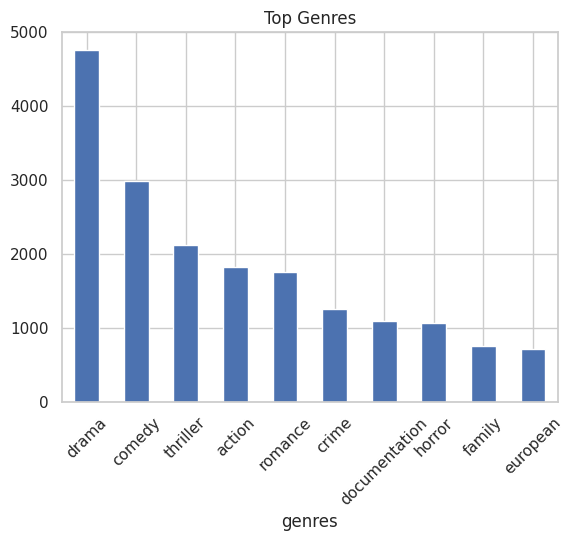

In [54]:
# Clean and split genres for accurate analysis
titles['genres'] = titles['genres'].astype(str)
titles['genres'] = titles['genres'].str.replace(r"[\[\]']", "", regex=True)
titles['genres'] = titles['genres'].str.split(',')

genres_exploded = titles.explode('genres')
genres_exploded['genres'] = genres_exploded['genres'].str.strip()

# Plot top genres
genres_exploded['genres'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.xticks(rotation=45)
plt.show()

The graph below shows how content production has grown over the years.

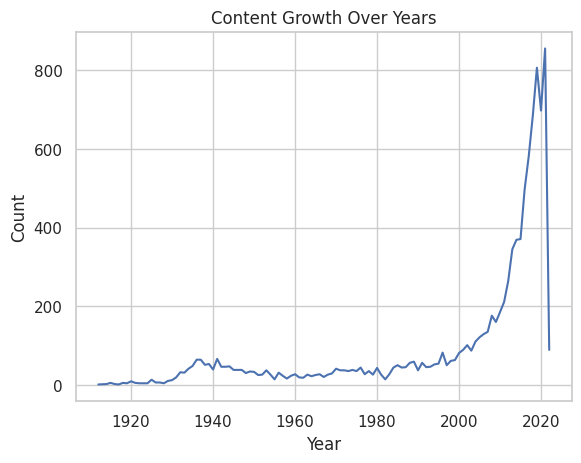

In [55]:
# Plot content growth over years
titles['release_year'].value_counts().sort_index().plot()
plt.title("Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

The graph below shows the distribution of IMDb ratings across the dataset.

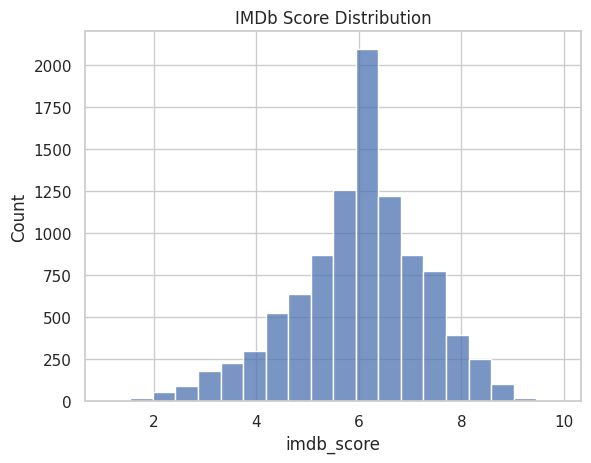

In [56]:
# Plot IMDb score distribution
sns.histplot(titles['imdb_score'], bins=20)
plt.title("IMDb Score Distribution")
plt.show()

This last graph shows the relationship between IMDb ratings and popularity.

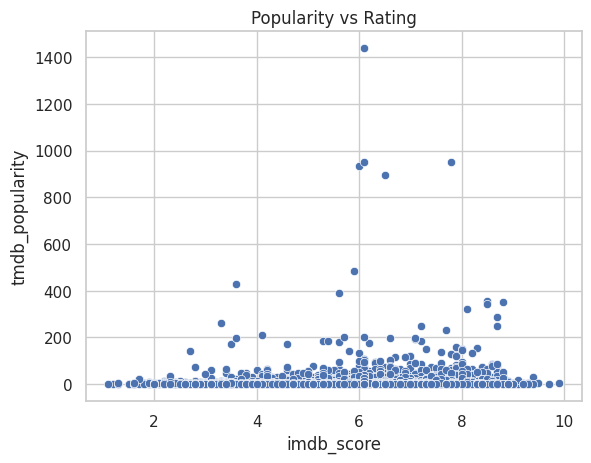

In [57]:
# Scatter plot for popularity vs rating
sns.scatterplot(x='imdb_score', y='tmdb_popularity', data=titles)
plt.title("Popularity vs Rating")
plt.show()

# ***6. Insights***

**1. Content Distribution**

The platform has significantly more movies than TV shows. This indicates that Amazon Prime focuses more on movie content compared to series-based content.

**2. Genre Analysis**

Drama is the most dominant genre, followed by comedy and thriller. This shows that emotional and entertainment-driven content is highly prevalent on the platform.

**3. Content Growth Over Time**

There is a sharp increase in content after 2010, with a major spike after 2015. This reflects the rapid expansion of streaming platforms and increased content production in recent years.

**4. IMDb Score Distribution**

Most of the content has IMDb ratings between 5 and 7, indicating average to moderately good quality content. Very few titles have extremely high or very low ratings.

**5. Popularity vs Rating**

There is no strong direct relationship between IMDb rating and popularity. Some highly rated content has low popularity, while some moderately rated content is highly popular, suggesting that popularity depends on multiple factors beyond ratings.

**6. Content Variety**

The presence of multiple genres like action, romance, crime, and documentary shows that Amazon Prime offers a diverse range of content catering to different audience preferences.

# ***7. Conclusion***

In this project, we performed exploratory data analysis on the Amazon Prime TV Shows and Movies dataset to understand content distribution, genre popularity, and trends over time.

The analysis showed that movies are more dominant than TV shows on the platform. Among genres, drama emerged as the most common, followed by other popular genres like comedy and thriller, indicating audience preference for engaging and emotional content.

A significant increase in content production was observed after 2015, reflecting the rapid growth of streaming platforms. The IMDb score distribution indicated that most content falls within an average rating range, suggesting moderate overall quality.

Additionally, the relationship between popularity and ratings showed that higher ratings do not always guarantee higher popularity, as multiple external factors influence audience engagement.

Overall, this analysis highlights key patterns in content strategy and user preferences, demonstrating how data analysis can be used to derive meaningful insights for decision-making in the entertainment industry.